# 🔧 Vehicle Complaint Classification using NLP

**Course:** Natural Language Processing (IN321)  
**Project Type:** Final Project  
**Semester:** February 2024

---

## 📄 Project Overview

This project aims to build an NLP-based system that **automatically classifies vehicle complaints** into fault categories using **customer-submitted text descriptions**. We utilize real-world data from the **NHTSA Complaints Dataset**.

---

## 📌 Problem Statement

Thousands of customer complaints are received daily by vehicle manufacturers and service centers. These are typically unstructured and manually reviewed.  
We aim to automate this process using an NLP classifier that categorizes each complaint (mechanical fault, system fault, etc.).

---

## 📁 Dataset Description

**Source:** [Kaggle - NHTSA Complaints Dataset](https://www.kaggle.com/datasets/alshival/nhtsa-complaints)

- Includes complaints from 2019 onward.
- Fields include:
  - `Complaint ID`
  - `Component` – the fault category.
  - `Description` – the customer complaint text.
  - Additional info like make, model, year.

**We'll focus on:**
- `Component`: target label for classification.
- `Description`: text input for NLP pipeline.

In [ ]:
import pandas as pd

In [ ]:
df_car = pd.read_csv('/content/car_models.csv')

In [ ]:
with open('/content/complaints.csv') as f:
    lines = f.readlines()
    print(lines[8215:8220])


['11047531,Hyundai Motor America,False,False,0,0,11/19/2017,11/20/2017,5XYZWDLA2HG,"VEHICLE SPEED CONTROL,UNKNOWN OR OTHER","I\'M STOPPED AT A STREET, WAITING TO TURN ON A MAIN ROAD.  I JUST HAVE A STOP SIGN, BUT THE CROSS TRAFFIC DOESN\'T HAVE TO STOP.  I START TO TURN OUT WHEN THERE\'S AN OPENING, AND MY CAR STALLS FOR A FEW SECONDS.  SOMETIMES IT\'S LONGER, SOMETIMES IT\'S SHORTER.  THIS HAS HAPPENED MULTIPLE TIMES.  IT MY CAR DOESN\'T GO QUICK ENOUGH, I COULD GET HIT.  I\'VE NOTICED THIS IS THE WORST WHEN I HAVE IT IN ECO MODE.  THIS EXACT THING HAPPENS WHEN I\'M ALSO TRYING TO ACCELERATE ONCE I\'VE MERGED ONTO A HIGHWAY.  IT\'S LIKE MY CAR IS STOPPING WHEN I\'M TRYING TO ACCELERATE TO GET TO THE PACE OF THE TRAFFIC ON THE HIGHWAY.","[{""type"": ""Vehicle"", ""productYear"": ""2017"", ""productMake"": ""HYUNDAI"", ""productModel"": ""SANTA FE SPORT"", ""manufacturer"": ""Hyundai Motor America""}]",HYUNDAI,SANTA FE SPORT,2017\n', '11047545,"General Motors, LLC",False,False,0,0,07/05

In [ ]:
import pandas as pd

df_comp = pd.read_csv(
    '/content/complaints.csv',
    engine='python',
    on_bad_lines='warn',
    quotechar='"',
    escapechar='\\'
)


In [ ]:
df_comp.head()

,odiNumber,manufacturer,crash,fire,numberOfInjuries,numberOfDeaths,dateOfIncident,dateComplaintFiled,vin,components,summary,products,make,model,modelYear
0,10702705,"Kia America, Inc.",True,False,0,0,03/24/2015,03/30/2015,5XYPG4A36GG,"SEAT BELTS,SEATS",SEAT BELT DID NOT UNLATCH AFTER CRASH. *TR,"[{""type"": ""Vehicle"", ""productYear"": ""2016"", ""p...",KIA,SORENTO,2016
1,10713088,"Kia America, Inc.",False,False,0,0,04/24/2015,04/27/2015,5XYPH4A15GG,STRUCTURE,"TRAVELING AT HIGHWAY SPEED, THE WINDSHIELD SEE...","[{""type"": ""Vehicle"", ""productYear"": ""2016"", ""p...",KIA,SORENTO,2016
2,10713503,"ALUMA TOWER COMPANY, INC",False,True,0,0,04/28/2015,04/29/2015,1YGAE1629GB,ELECTRICAL SYSTEM,TL* THE CONTACT OWNS A 2016 ALUMA AE716TA TRAI...,"[{""type"": ""Vehicle"", ""productYear"": ""2016"", ""p...",ALUMA,AE716TA,2016
3,10715078,"Kia America, Inc.",False,False,0,0,04/30/2015,05/07/2015,NaN,STEERING,"WHILE TRAVELING AT HIGHWAY SPEEDS, THE SORENTO...","[{""type"": ""Vehicle"", ""productYear"": ""2016"", ""p...",KIA,SORENTO,2016
4,10715844,Volvo Trucks North America,False,False,0,0,03/06/2015,05/12/2015,4V4NC9EH7GN,SUSPENSION,SINCE THE PURCHASE OF THIS VEHICLE IT HAS AN U...,"[{""type"": ""Vehicle"", ""productYear"": ""2016"", ""p...",VOLVO,780,2016


In [ ]:
import pandas as pd


num_classes = df_comp['components'].nunique()
print("Number of classes:", num_classes)

Number of classes: 740


In [ ]:
import pandas as pd

class_counts = df_comp['components'].value_counts()
print(class_counts)


components
UNKNOWN OR OTHER                                                      2096
POWER TRAIN                                                           1909
ENGINE                                                                1378
ELECTRICAL SYSTEM                                                      943
SERVICE BRAKES                                                         900
                                                                      ... 
VEHICLE SPEED CONTROL,VISIBILITY/WIPER                                   1
VISIBILITY/WIPER,BACK OVER PREVENTION                                    1
ELECTRONIC STABILITY CONTROL (ESC),VISIBILITY/WIPER,LANE DEPARTURE       1
TRAILER HITCHES,EQUIPMENT,STRUCTURE                                      1
FUEL/PROPULSION SYSTEM,ELECTRICAL SYSTEM                                 1
Name: count, Length: 740, dtype: int64


In [ ]:
component_counts = df_comp['components'].value_counts()

print("Top 10 component counts:")
print(component_counts.head(10))

top_20_components = component_counts.head(20).index.tolist()


filtered_df = df_comp[df_comp['components'].isin(top_20_components)].copy()


print("Number of classes after filtering:", filtered_df['components'].nunique())
print(filtered_df['components'].value_counts())


Top 10 component counts:
components
UNKNOWN OR OTHER          2096
POWER TRAIN               1909
ENGINE                    1378
ELECTRICAL SYSTEM          943
SERVICE BRAKES             900
STEERING                   891
AIR BAGS                   704
STRUCTURE                  687
VISIBILITY/WIPER           640
FUEL/PROPULSION SYSTEM     587
Name: count, dtype: int64
Number of classes after filtering: 20
components
UNKNOWN OR OTHER                 2096
POWER TRAIN                      1909
ENGINE                           1378
ELECTRICAL SYSTEM                 943
SERVICE BRAKES                    900
STEERING                          891
AIR BAGS                          704
STRUCTURE                         687
VISIBILITY/WIPER                  640
FUEL/PROPULSION SYSTEM            587
EXTERIOR LIGHTING                 579
VEHICLE SPEED CONTROL             537
WHEELS                            358
POWER TRAIN,ENGINE                243
ENGINE,FUEL/PROPULSION SYSTEM     229
SUSPENSIO

In [ ]:
all_top_20 = top_20_components
df_comp['components_grouped'] = df_comp['components'].apply(
    lambda x: x if x in all_top_20 else 'Other'
)

print(df_comp['components_grouped'].value_counts())


components_grouped
Other                            5499
UNKNOWN OR OTHER                 2096
POWER TRAIN                      1909
ENGINE                           1378
ELECTRICAL SYSTEM                 943
SERVICE BRAKES                    900
STEERING                          891
AIR BAGS                          704
STRUCTURE                         687
VISIBILITY/WIPER                  640
FUEL/PROPULSION SYSTEM            587
EXTERIOR LIGHTING                 579
VEHICLE SPEED CONTROL             537
WHEELS                            358
POWER TRAIN,ENGINE                243
ENGINE,FUEL/PROPULSION SYSTEM     229
SUSPENSION                        216
SEAT BELTS                        214
ELECTRICAL SYSTEM,ENGINE          208
SEATS                             206
UNKNOWN OR OTHER,ENGINE           156
Name: count, dtype: int64


In [ ]:
print(df_comp['components_grouped'].value_counts())


components_grouped
Other                            5499
UNKNOWN OR OTHER                 2096
POWER TRAIN                      1909
ENGINE                           1378
ELECTRICAL SYSTEM                 943
SERVICE BRAKES                    900
STEERING                          891
AIR BAGS                          704
STRUCTURE                         687
VISIBILITY/WIPER                  640
FUEL/PROPULSION SYSTEM            587
EXTERIOR LIGHTING                 579
VEHICLE SPEED CONTROL             537
WHEELS                            358
POWER TRAIN,ENGINE                243
ENGINE,FUEL/PROPULSION SYSTEM     229
SUSPENSION                        216
SEAT BELTS                        214
ELECTRICAL SYSTEM,ENGINE          208
SEATS                             206
UNKNOWN OR OTHER,ENGINE           156
Name: count, dtype: int64


In [ ]:
from sklearn.utils import resample

counts = df_comp['components_grouped'].value_counts()
majority_class = counts.idxmax()
minority_class = counts.idxmin()

df_majority = df_comp[df_comp['components_grouped'] == majority_class]
df_minority = df_comp[df_comp['components_grouped'] == minority_class]


df_majority_downsampled = resample(df_majority,
                                   replace=False,
                                   n_samples=len(df_minority),
                                   random_state=42)

df_minority_rest = df_comp[df_comp['components_grouped'] != majority_class]
df_balanced = pd.concat([df_majority_downsampled, df_minority_rest])

print(df_balanced['components_grouped'].value_counts())


components_grouped
UNKNOWN OR OTHER                 2096
POWER TRAIN                      1909
ENGINE                           1378
ELECTRICAL SYSTEM                 943
SERVICE BRAKES                    900
STEERING                          891
AIR BAGS                          704
STRUCTURE                         687
VISIBILITY/WIPER                  640
FUEL/PROPULSION SYSTEM            587
EXTERIOR LIGHTING                 579
VEHICLE SPEED CONTROL             537
WHEELS                            358
POWER TRAIN,ENGINE                243
ENGINE,FUEL/PROPULSION SYSTEM     229
SUSPENSION                        216
SEAT BELTS                        214
ELECTRICAL SYSTEM,ENGINE          208
SEATS                             206
Other                             156
UNKNOWN OR OTHER,ENGINE           156
Name: count, dtype: int64


In [ ]:
from sklearn.utils import resample

counts = df_comp['components_grouped'].value_counts()
majority_class = counts.idxmax()
majority_size = counts.max()

df_balanced_list = []

for cls in counts.index:
    df_cls = df_comp[df_comp['components_grouped'] == cls]
    if len(df_cls) < majority_size:

        df_cls_upsampled = resample(df_cls,
                                    replace=True,
                                    n_samples=majority_size,
                                    random_state=42)
        df_balanced_list.append(df_cls_upsampled)
    else:
        df_balanced_list.append(df_cls)

df_balanced = pd.concat(df_balanced_list)
print(df_balanced['components_grouped'].value_counts())


components_grouped
Other                            5499
UNKNOWN OR OTHER                 5499
POWER TRAIN                      5499
ENGINE                           5499
ELECTRICAL SYSTEM                5499
SERVICE BRAKES                   5499
STEERING                         5499
AIR BAGS                         5499
STRUCTURE                        5499
VISIBILITY/WIPER                 5499
FUEL/PROPULSION SYSTEM           5499
EXTERIOR LIGHTING                5499
VEHICLE SPEED CONTROL            5499
WHEELS                           5499
POWER TRAIN,ENGINE               5499
ENGINE,FUEL/PROPULSION SYSTEM    5499
SUSPENSION                       5499
SEAT BELTS                       5499
ELECTRICAL SYSTEM,ENGINE         5499
SEATS                            5499
UNKNOWN OR OTHER,ENGINE          5499
Name: count, dtype: int64


In [ ]:
import pandas as pd


num_classes = df_comp['components_grouped'].nunique()
print("Number of classes:", num_classes)

Number of classes: 21


In [ ]:
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)


In [ ]:
df_comp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19180 entries, 0 to 19179
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   odiNumber           19180 non-null  int64  
 1   manufacturer        19180 non-null  object 
 2   crash               19180 non-null  bool   
 3   fire                19180 non-null  bool   
 4   numberOfInjuries    19180 non-null  int64  
 5   numberOfDeaths      19180 non-null  int64  
 6   dateOfIncident      19180 non-null  object 
 7   dateComplaintFiled  19180 non-null  object 
 8   vin                 17532 non-null  object 
 9   components          19180 non-null  object 
 10  summary             19179 non-null  object 
 11  products            19180 non-null  object 
 12  make                19179 non-null  object 
 13  model               19179 non-null  object 
 14  modelYear           19179 non-null  float64
 15  components_grouped  19180 non-null  object 
dtypes: b

In [ ]:
df_comp.describe()

,odiNumber,numberOfInjuries,numberOfDeaths,modelYear
count,1.918000e+04,19180.000000,19180.000000,19179.000000
mean,1.104415e+07,0.070334,0.001147,2016.684551
std,9.120425e+04,0.347960,0.039533,0.786910
min,1.070270e+07,0.000000,0.000000,2016.000000
25%,1.098369e+07,0.000000,0.000000,2016.000000
50%,1.106623e+07,0.000000,0.000000,2016.000000
75%,1.111965e+07,0.000000,0.000000,2017.000000
max,1.116303e+07,8.000000,2.000000,2019.000000


In [ ]:
df_comp.isnull().sum()

,0
odiNumber,0
manufacturer,0
crash,0
fire,0
numberOfInjuries,0
numberOfDeaths,0
dateOfIncident,0
dateComplaintFiled,0
vin,1648
components,0


✅ You should NOT use it as a feature for classification:
VINs are unique identifiers, not descriptive or predictive features.

Including vin as an input feature will confuse your model (overfitting on IDs).

| Feature                      | Use for Modeling? | Why?                                  |
| ---------------------------- | ----------------- | ------------------------------------- |
| `vin`                        | ❌                 | Unique, no predictive value           |
| `Description`                | ✅                 | Main text input for NLP               |
| `Component`                  | ✅                 | Target label (what you're predicting) |
| `Make`, `Model`, `ModelYear` | ✅                 | Helpful metadata features             |


In [ ]:
df_comp = df_comp.drop(columns=['vin'])


In [ ]:
 df_comp.columns

Index(['odiNumber', 'manufacturer', 'crash', 'fire', 'numberOfInjuries',
       'numberOfDeaths', 'dateOfIncident', 'dateComplaintFiled', 'components',
       'summary', 'products', 'make', 'model', 'modelYear',
       'components_grouped'],
      dtype='object')

In [ ]:
df_comp.isnull().sum()

,0
odiNumber,0
manufacturer,0
crash,0
fire,0
numberOfInjuries,0
numberOfDeaths,0
dateOfIncident,0
dateComplaintFiled,0
components,0
summary,1


<ipython-input-37-3ae37f509f72>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_components.values, y=top_components.index, palette='viridis')


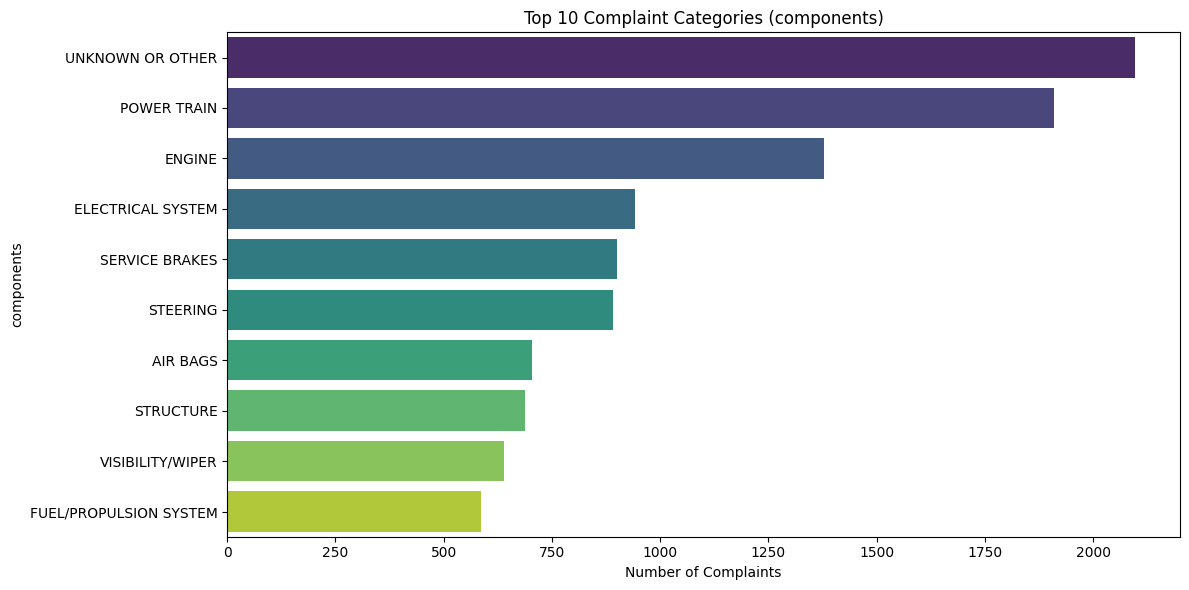

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))
top_components = df_comp['components'].value_counts().head(10)

sns.barplot(x=top_components.values, y=top_components.index, palette='viridis')
plt.title('Top 10 Complaint Categories (components)')
plt.xlabel('Number of Complaints')
plt.ylabel('components')
plt.tight_layout()
plt.show()


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


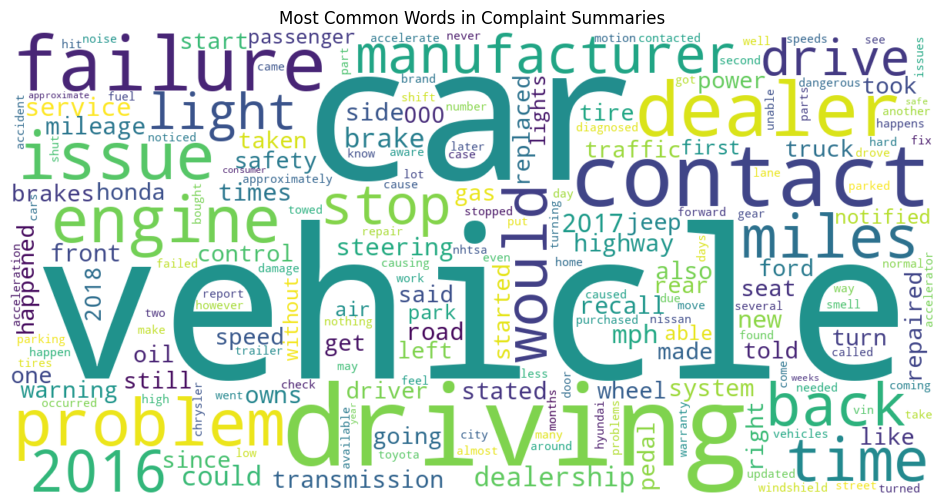

In [ ]:
from collections import Counter
from wordcloud import WordCloud
import nltk
import re

nltk.download('stopwords')
stop_words = set(nltk.corpus.stopwords.words('english'))

text = ' '.join(df_comp['summary'].dropna().astype(str).tolist())
words = re.findall(r'\b\w+\b', text.lower())
filtered_words = [w for w in words if w not in stop_words and len(w) > 2]

word_freq = Counter(filtered_words)
wc = WordCloud(width=1200, height=600, background_color='white').generate_from_frequencies(word_freq)

plt.figure(figsize=(12,6))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words in Complaint Summaries')
plt.show()


<ipython-input-23-7d5a0bcbb71e>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_makes.index, x=top_makes.values, palette='mako')


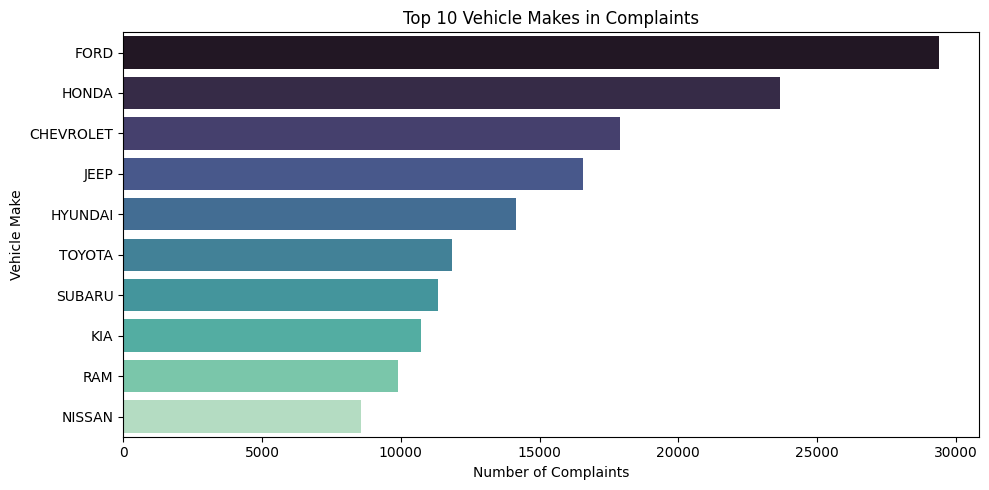

In [ ]:
plt.figure(figsize=(10,5))
top_makes = df_comp['make'].str.upper().value_counts().head(10)

sns.barplot(y=top_makes.index, x=top_makes.values, palette='mako')
plt.title('Top 10 Vehicle Makes in Complaints')
plt.xlabel('Number of Complaints')
plt.ylabel('Vehicle Make')
plt.tight_layout()
plt.show()


# Text Preprocessing

In [ ]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer


In [ ]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):

    text = text.lower()

    text = re.sub(r'[^a-z\s]', '', text)

    words = text.split()

    words = [word for word in words if word not in stop_words]

    words = [lemmatizer.lemmatize(word) for word in words]

    return ' '.join(words)


In [ ]:
import nltk
nltk.download('wordnet')


[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [ ]:
df_comp['clean_summary'] = df_comp['summary'].astype(str).apply(preprocess_text)


In [ ]:
print(df_comp[['summary', 'clean_summary']].head())


                                             summary  \
0        SEAT BELT DID NOT UNLATCH AFTER CRASH.  *TR   
1  TRAVELING AT HIGHWAY SPEED, THE WINDSHIELD SEE...   
2  TL* THE CONTACT OWNS A 2016 ALUMA AE716TA TRAI...   
3  WHILE TRAVELING AT HIGHWAY SPEEDS, THE SORENTO...   
4  SINCE THE PURCHASE OF THIS VEHICLE IT HAS AN U...   

                                       clean_summary  
0                         seat belt unlatch crash tr  
1  traveling highway speed windshield seemed suff...  
2  tl contact owns aluma aeta trailer na parked c...  
3  traveling highway speed sorento constantly swa...  
4  since purchase vehicle uncontrollable cab sway...  


# Vectorization

## 1. TF-IDF Vectorization

TF-IDF (Term Frequency–Inverse Document Frequency) is simple and fast for traditional models like Logistic Regression or SVM.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000,
                        ngram_range=(1,2),
                        stop_words='english')

tfidf_matrix = tfidf.fit_transform(df_comp['clean_summary'])

print("TF-IDF matrix shape:", tfidf_matrix.shape)


TF-IDF matrix shape: (19180, 5000)


In [ ]:
import torch
from transformers import DistilBertTokenizer, DistilBertModel

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')
model = DistilBertModel.from_pretrained('distilbert-base-uncased').to(device)
model.eval()

def get_bert_embeddings(text_list, batch_size=32):
    embeddings = []
    for i in range(0, len(text_list), batch_size):
        batch_texts = text_list[i:i+batch_size]
        encoded_input = tokenizer(batch_texts, padding=True, truncation=True, max_length=128, return_tensors='pt')
        encoded_input = {k:v.to(device) for k,v in encoded_input.items()}
        with torch.no_grad():
            outputs = model(**encoded_input)

        batch_embeddings = outputs.last_hidden_state[:,0,:].cpu().numpy()
        embeddings.append(batch_embeddings)
    return np.vstack(embeddings)

texts = df_comp['clean_summary'].astype(str).tolist()
bert_embeddings = get_bert_embeddings(texts)


KeyboardInterrupt: 

# modeling

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report


In [ ]:
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), stop_words='english')
X = tfidf.fit_transform(df_comp['clean_summary'])

In [ ]:
le = LabelEncoder()
y = le.fit_transform(df_comp['components_grouped'])

In [ ]:

print("\nNumber of Classes:", len(le.classes_))


Number of Classes: 21


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
svm = SVC(kernel='linear', C=1)
svm.fit(X_train, y_train)

SVC(C=1, kernel='linear')

In [ ]:
y_pred = svm.predict(X_test)

print("\n=== SVM Classification Report ===")
print(classification_report(y_test, y_pred, target_names=le.classes_))


=== SVM Classification Report ===
                               precision    recall  f1-score   support

                     AIR BAGS       0.70      0.81      0.75       141
            ELECTRICAL SYSTEM       0.54      0.30      0.38       189
     ELECTRICAL SYSTEM,ENGINE       0.00      0.00      0.00        42
                       ENGINE       0.52      0.51      0.52       276
ENGINE,FUEL/PROPULSION SYSTEM       0.00      0.00      0.00        46
            EXTERIOR LIGHTING       0.77      0.77      0.77       116
       FUEL/PROPULSION SYSTEM       0.65      0.49      0.56       117
                        Other       0.44      0.65      0.52      1100
                  POWER TRAIN       0.64      0.62      0.63       382
           POWER TRAIN,ENGINE       0.00      0.00      0.00        49
                   SEAT BELTS       0.80      0.74      0.77        43
                        SEATS       0.87      0.63      0.73        41
               SERVICE BRAKES       0.70 

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical

In [ ]:
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X = vectorizer.fit_transform(df_comp['clean_summary']).toarray()  # TF-IDF → dense array

le = LabelEncoder()
y = le.fit_transform(df_comp['components_grouped'])


y_cat = to_categorical(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_cat, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
from sklearn.preprocessing import MaxAbsScaler

scaler = MaxAbsScaler()
X_scaled = scaler.fit_transform(X)


In [ ]:
X = vectorizer.fit_transform(df_comp['clean_summary']).toarray()


In [ ]:
model = Sequential([
    Dense(512, activation='relu', input_shape=(X.shape[1],)),
    Dropout(0.5),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(y_cat.shape[1], activation='softmax')
])


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)


In [ ]:
history = model.fit(
    X_train, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)


Epoch 1/5
216/216 ━━━━━━━━━━━━━━━━━━━━ 27s 94ms/step - accuracy: 0.3021 - loss: 2.4629 - val_accuracy: 0.5199 - val_loss: 1.4487
Epoch 2/5
216/216 ━━━━━━━━━━━━━━━━━━━━ 32s 51ms/step - accuracy: 0.5926 - loss: 1.2459 - val_accuracy: 0.5414 - val_loss: 1.3441
Epoch 3/5
216/216 ━━━━━━━━━━━━━━━━━━━━ 10s 45ms/step - accuracy: 0.6973 - loss: 0.9101 - val_accuracy: 0.5140 - val_loss: 1.4080
Epoch 4/5
216/216 ━━━━━━━━━━━━━━━━━━━━ 11s 51ms/step - accuracy: 0.7877 - loss: 0.6631 - val_accuracy: 0.5225 - val_loss: 1.5463
Epoch 5/5
216/216 ━━━━━━━━━━━━━━━━━━━━ 11s 53ms/step - accuracy: 0.8439 - loss: 0.4831 - val_accuracy: 0.5081 - val_loss: 1.7268


In [ ]:
loss, acc = model.evaluate(X_test, y_test)
print(f"\nTest Accuracy: {acc:.4f}")

120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5180 - loss: 1.7166

Test Accuracy: 0.5185


In [ ]:
import pandas as pd
import re
import nltk
import torch
from datasets import Dataset
from sklearn.preprocessing import LabelEncoder
from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification, TrainingArguments, Trainer
from sklearn.metrics import accuracy_score, f1_score, classification_report

In [ ]:
label_encoder = LabelEncoder()
df_comp['label'] = label_encoder.fit_transform(df_comp['components_grouped'])


tokenizer = DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")

hf_dataset = Dataset.from_pandas(df_comp[['clean_summary', 'label']].rename(columns={"clean_summary": "text"}))

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

In [ ]:
def tokenize_function(example):
    return tokenizer(example["text"], padding="max_length", truncation=True, max_length=128)

tokenized_datasets = hf_dataset.map(tokenize_function, batched=True)
tokenized_datasets = tokenized_datasets.train_test_split(test_size=0.2)


Map:   0%|          | 0/19180 [00:00<?, ? examples/s]

In [ ]:

num_labels = len(label_encoder.classes_)
model = DistilBertForSequenceClassification.from_pretrained("distilbert-base-uncased", num_labels=num_labels)


Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
def compute_metrics(p):
    preds = torch.argmax(torch.tensor(p.predictions), axis=1)
    labels = torch.tensor(p.label_ids)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1": f1_score(labels, preds, average="weighted"),
    }

In [ ]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./results",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=4,
    weight_decay=0.01,
    logging_dir="./logs",
    logging_steps=100
)


In [ ]:
import transformers
print(transformers.__version__)


4.52.2


In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["test"],
    compute_metrics=compute_metrics,
)

In [ ]:

trainer.train()

wandb: WARNING The `run_name` is currently set to the same value as `TrainingArguments.output_dir`. If this was not intended, please specify a different run name by setting the `TrainingArguments.run_name` parameter.


<IPython.core.display.Javascript object>

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize?ref=models
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: mh9786636 (mh9786636-arab-academy-for-science-technology-maritime-t) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Step,Training Loss
100,2.635600
200,2.356500
300,1.960400
400,1.708500


In [ ]:
preds_output = trainer.predict(tokenized_datasets["test"])
y_true = preds_output.label_ids
y_pred = preds_output.predictions.argmax(axis=1)

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=label_encoder.classes_))